# 3 · Correlations: $g^{(2)}$, Hanbury Brown–Twiss, and How We Make & Catch Photons

**Lecture · Tuesday July 28, 9:00–10:00 · Tim Thomay**

### Learning objectives

1. define $g^{(2)}(\tau)$, prove the classical bound $g^{(2)}(0)\ge 1$, and state the quantum values for coherent, thermal, and Fock states,
2. explain why the **HBT** beamsplitter geometry measures $g^{(2)}$ even with slow, dead-time-limited detectors — and how the same trick measured the diameter of Sirius,
3. compare single-photon **sources** and **detectors** by the figures of merit that actually matter.

*Key papers: [HanburyBrown1956], [Glauber1963], [Kimble1977]; reviews [Natarajan2012], [MeyerScott2020] — all in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
import qutip

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(7)

## 3.0 · Warm-up quiz (2 minutes, shout the answers)

1. Attenuate a laser to $\bar n = 0.01$ per pulse. Mandel $Q$ of the output?
2. For thermal light, which $n$ has the highest probability — at *any* $\bar n$?
3. Yesterday's stretch exercise: Fock $|4\rangle$ after 75% loss — still non-classical?
4. Why don't you see Bose–Einstein statistics when pointing a photodiode at the sun?

## 3.1 · 1956: two radio astronomers scandalize quantum physics

Robert Hanbury Brown was a radar engineer turned radio astronomer; Richard Twiss, a mathematician. Their problem was mundane: **measure the angular diameter of stars**, which Michelson-type amplitude interferometry couldn't do for most stars (atmospheric phase noise destroys the fringes over long baselines).

Their idea was heretical: don't correlate *fields* — correlate **intensities**. Two photodetectors, two telescopes, a cable, a multiplier. Intensity fluctuations of thermal light are correlated between nearby detectors (the light "flickers together"), and the correlation dies off as the detectors separate beyond a coherence area set by the star's angular size. No fringes, no phase stability needed.

Radio astronomers shrugged — classical waves, obviously fine. But when HBT ran the *tabletop optical version* [HanburyBrown1956] — a mercury lamp, a half-silvered mirror, two photomultipliers — and found **correlated photon arrivals** (bunching), parts of the physics community revolted. Photons are independent particles, the argument went; correlated detection of independently emitted photons seemed to violate everything. Brannen and Ferguson published a failed replication and wrote that if HBT were right, it "would call for a major revision of some fundamental concepts of quantum mechanics." Purcell [Purcell1956] settled it with a beautiful short paper: bunching is exactly what boson statistics + classical intensity fluctuations demand (the replication had simply lacked time resolution — remember multimode washout from yesterday!).

The aftermath built our field:

* **1956–1972**: the Narrabri intensity interferometer measures the diameters of 32 stars, Sirius first — HBT's original goal, achieved.
* **1963**: Glauber constructs the full quantum theory of optical coherence [Glauber1963] — the $g^{(n)}$ hierarchy we use today (Nobel 2005).
* **1977**: Kimble, Dagenais & Mandel observe **antibunching** in single-atom fluorescence [Kimble1977] — the first phenomenon with *no* classical explanation. (With Grangier–Roger–Aspect's 1986 single-photon beamsplitter experiment [Grangier1986] as the definitive "the photon exists" demonstration.)
* **today**: every quantum-dot paper, every SPDC source, every photonic-QC wafer is qualified by the same measurement you will run after the coffee break.

## 3.2 · $P(n)$ says nothing about *time*

Yesterday's click streams showed thermal photons arriving in clusters and single-emitter photons keeping their distance — structure invisible in $P(n)$ over long windows. The right question:

> *given a detection at time $t$, how likely is another detection at $t + \tau$?*

That is the **second-order (intensity) correlation function** [Glauber1963]:

$$g^{(2)}(\tau) = \frac{\langle \hat a^\dagger(t)\, \hat a^\dagger(t+\tau)\, \hat a(t+\tau)\, \hat a(t)\rangle}{\langle \hat a^\dagger \hat a\rangle^2}
\;\;\xrightarrow{\;\tau = 0,\ \text{single mode}\;}\;\;
g^{(2)}(0) = \frac{\langle \hat n(\hat n - 1)\rangle}{\langle \hat n\rangle^2}.$$

Note the **normal ordering** ($\hat a^\dagger$s left, $\hat a$s right): the first detection *removes* a photon, so $g^{(2)}$ automatically asks what the field looks like *after* one detection. $\langle\hat n(\hat n-1)\rangle$ counts ordered photon **pairs**.

### The classical bound, in two lines

For any *classical* intensity ensemble $\{I\}$: $g^{(2)}(0) = \langle I^2\rangle/\langle I\rangle^2$, and

$$\langle I^2 \rangle - \langle I \rangle^2 = \left\langle (I - \langle I\rangle)^2 \right\rangle \ge 0
\quad\Longrightarrow\quad \boxed{g^{(2)}_{\rm cl}(0) \ge 1}.$$

A classical field can flicker (pushing $g^{(2)}$ up) but can never *anti*-flicker below 1 — an intensity cannot fluctuate below zero. Also, by Cauchy–Schwarz, classical light always **bunches**: $g^{(2)}_{\rm cl}(\tau) \le g^{(2)}_{\rm cl}(0)$. Antibunching — a *rising* $g^{(2)}$ out of $\tau=0$ — is doubly forbidden classically.

### The quantum values

In [2]:
# g2(0) for the three families - three lines of QuTiP.
def g2_zero(state) -> float:
    """g2(0) = <n(n-1)> / <n>^2 for a single-mode state (ket or dm)."""
    n_op = qutip.num(state.shape[0])
    mean_n = qutip.expect(n_op, state)
    pairs = qutip.expect(n_op * (n_op - 1), state)   # <a+ a+ a a>
    return pairs / mean_n**2

N = 60
print("thermal nbar=2 :", f"{g2_zero(qutip.thermal_dm(N, 2.0)):.3f}   (theory: 2)")
print("coherent       :", f"{g2_zero(qutip.coherent(N, 2.0)):.3f}   (theory: 1)")
for n in [1, 2, 3, 4]:
    print(f"Fock |{n}>       : {g2_zero(qutip.fock(N, n)):.3f}   "
          f"(theory: 1 - 1/{n} = {1 - 1/n:.3f})")

thermal nbar=2 : 2.000   (theory: 2)
coherent       : 1.000   (theory: 1)
Fock |1>       : 0.000   (theory: 1 - 1/1 = 0.000)
Fock |2>       : 0.500   (theory: 1 - 1/2 = 0.500)
Fock |3>       : 0.667   (theory: 1 - 1/3 = 0.667)
Fock |4>       : 0.750   (theory: 1 - 1/4 = 0.750)


$$g^{(2)}(0) = 2 \;\text{(thermal)}, \qquad 1 \;\text{(coherent)}, \qquad 1 - \tfrac1n \;\text{(Fock)}.$$

Boundaries to memorize:

* **$g^{(2)}(0) < 1$ = antibunching = non-classical.** Full stop.
* **$g^{(2)}(0) < 1/2$** is the practical *single*-photon certificate: it excludes any state whose two-photon component is as large as $|2\rangle$'s ($g^{(2)}(0) = 1/2$).
* Relation to yesterday (single mode, zero delay): $g^{(2)}(0) = 1 + \dfrac{Q}{\bar n}$. But note the exchange rate: for faint light ($\bar n \ll 1$) a tiny $|Q|$ is a huge $g^{(2)}$ deviation — **this is why single-photon physics measures $g^{(2)}$, not $Q$**. And unlike $Q$, $g^{(2)}$ is *invariant under loss* (both $\langle n(n-1)\rangle$ and $\langle n\rangle^2$ scale as $\eta^2$) — the witness that survives a lossy lab.

### The shapes in time

Away from $\tau = 0$ every stationary source decorrelates: $g^{(2)}(\infty) = 1$.

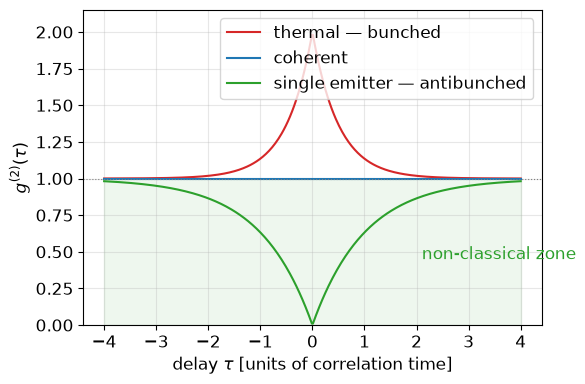

In [3]:
# The canonical g2(tau) shapes (analytic single-mode models).
tau = np.linspace(-4, 4, 400)          # in units of the correlation time

g2_thermal = 1 + np.exp(-2 * np.abs(tau))     # chaotic light (Lorentzian spectrum)
g2_coherent = np.ones_like(tau)
g2_emitter = 1 - np.exp(-np.abs(tau))         # two-level emitter, weak driving

fig, ax = plt.subplots()
ax.plot(tau, g2_thermal, color="tab:red", label="thermal — bunched")
ax.plot(tau, g2_coherent, color="tab:blue", label="coherent")
ax.plot(tau, g2_emitter, color="tab:green", label="single emitter — antibunched")
ax.axhline(1, color="gray", lw=0.8, ls=":")
ax.fill_between(tau, 0, 1, alpha=0.08, color="tab:green")
ax.annotate("non-classical zone", (2.1, 0.45), color="tab:green")
ax.set_xlabel(r"delay $\tau$ [units of correlation time]")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.set_ylim(0, 2.15)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Example — reading a real trace.** The antibunching dip is not just a dip; its *shape* is emitter spectroscopy for free. For a resonantly driven two-level atom (Rabi frequency $\Omega$, decay rate $\Gamma$):

$$g^{(2)}(\tau) = 1 - e^{-\frac{3\Gamma}{4}|\tau|}\left[\cos\Omega'|\tau| + \frac{3\Gamma}{4\Omega'}\sin\Omega'|\tau|\right],
\qquad \Omega' = \sqrt{\Omega^2 - (\Gamma/4)^2}.$$

Weak driving: a smooth recovery on the lifetime scale. Strong driving: the photon stream *oscillates* — after each emission the atom coherently cycles, and $g^{(2)}$ rings at the Rabi frequency. People fit $\Gamma$ **and** $\Omega$ straight from a photon-correlation histogram:

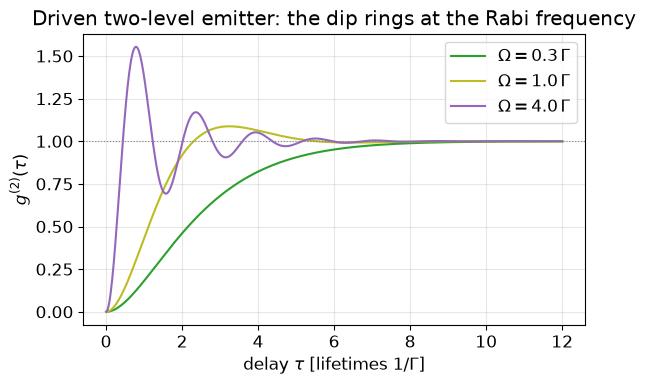

In [4]:
# Antibunching dip of a driven two-level emitter: weak vs strong driving.
Gamma = 1.0                                     # decay rate [1/lifetime]
tau = np.linspace(0, 12, 600)                   # delay [lifetimes]

fig, ax = plt.subplots()
for Omega, color in [(0.3, "tab:green"), (1.0, "tab:olive"), (4.0, "tab:purple")]:
    Op = np.sqrt(complex(Omega**2 - (Gamma / 4)**2))
    g2 = 1 - np.exp(-0.75 * Gamma * tau) * np.real(
        np.cos(Op * tau) + (0.75 * Gamma / Op) * np.sin(Op * tau))
    ax.plot(tau, g2, color=color, label=f"$\\Omega = {Omega}\\,\\Gamma$")
ax.axhline(1, color="gray", lw=0.8, ls=":")
ax.set_xlabel(r"delay $\tau$ [lifetimes $1/\Gamma$]")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.set_title("Driven two-level emitter: the dip rings at the Rabi frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 3.3 · Hanbury Brown–Twiss: how to actually measure $g^{(2)}$

**The problem.** Resolving photon pairs a few ns apart with *one* detector is impossible: a single-photon detector goes blind for 20–100 ns after each click (**dead time**), precisely where the physics is.

**The trick** [HanburyBrown1956]: split the beam 50:50, one detector per output, and histogram the arrival-time differences **between** the channels — the two detectors don't share dead time.

```
                   ┌── D1 ──┐   start
 source ──── BS ───┤        ├──▶ correlator ──▶ histogram ∝ g⁽²⁾(τ)
              │    └── D2 ──┘   stop
              ▼
            (50:50)
```

The normalized coincidence histogram **is** $g^{(2)}(\tau)$. The beamsplitter does *not* alter the statistics — splitting is binomial thinning (yesterday's stretch exercise), and $g^{(2)}$ is loss-invariant.

Practicalities you will need in one hour:

* **Normalization**: uncorrelated streams at rates $r_1, r_2$ produce $r_1 r_2 T \Delta\tau$ *accidental* coincidences per bin of width $\Delta\tau$ in total time $T$. Divide by that → flat = 1 automatically.
* **Start–stop vs streaming**: classic HBT electronics recorded only the *next* stop after each start — fine for $r\tau_c \ll 1$, but it distorts the histogram at high rates. Modern time taggers record *every* tag; you correlate **all pairs** in software. Our data is of the streaming kind.
* **Error bars**: coincidence counts are Poissonian, so a bin with $N_c$ counts carries $\sqrt{N_c}$ uncertainty. "The dip touches zero" is a statement about statistics, not just about the source.

### The stellar version — why this measures the diameter of Sirius

Between two telescopes separated by baseline $d$, thermal-light intensity correlations decay as the source stops being point-like: $g^{(2)}(d) - 1 = |\gamma(d)|^2$, where $\gamma$ is the field coherence (van Cittert–Zernike). The correlation vanishes when $d \gtrsim \lambda/\theta_\star$. For Sirius ($\theta_\star \approx 6$ milli-arcsec $\approx 3\times10^{-8}$ rad, $\lambda = 400$ nm): $d_{\rm crit} \approx \lambda/\theta_\star \approx 14$ m. Narrabri's tracks ran to 188 m — comfortable. Phase noise from the atmosphere? Irrelevant: intensities carry no phase. That robustness is *the* engineering virtue of intensity correlations, then for starlight, today for quantum optics: **HBT works when interferometers can't.**

## 3.4 · Higher orders: $g^{(3)}$, $g^{(4)}$, …

With more beamsplitters and detectors:

$$g^{(k)}(0) = \frac{\langle \hat n (\hat n -1)\cdots(\hat n - k + 1)\rangle}{\langle \hat n\rangle^k}
\qquad\text{(counts ordered $k$-tuples)}.$$

| state | $g^{(2)}(0)$ | $g^{(3)}(0)$ | $g^{(4)}(0)$ |
|---|---|---|---|
| coherent | 1 | 1 | 1 |
| thermal | 2 | **6** | 24 — $k!$: bunching compounds |
| Fock $\lvert 2\rangle$ | 1/2 | **0** | 0 |
| Fock $\lvert 3\rangle$ | 2/3 | 2/9 | 0 |

Why bother? Because $g^{(2)}$ alone can be fooled: a noisy single-photon source and a clean $\lvert 2\rangle$ can share $g^{(2)}(0) = 0.5$ — but $g^{(3)}$ separates them instantly (0 for $\lvert 2\rangle$). Higher-order correlations are also how photon-number-resolving power is certified, and thermal $g^{(3)} = 3!$ is a beautiful classroom check of the $k!$ law.

## 3.5 · Making quantum light

| source | mechanism | statistics | the catch |
|---|---|---|---|
| **attenuated laser** | loss on coherent state | Poisson, $g^{(2)}=1$ | *never* becomes single-photon |
| **SPDC / four-wave mixing** | pump photon → signal+idler **pair** | each arm alone: *thermal*! pairs: perfectly correlated | probabilistic; multi-pair events grow with pump |
| **heralded SPDC** | detect idler ⇒ herald signal | $\to$ Fock $\lvert 1\rangle$ ($\lvert 2\rangle$… with PNR herald) | rate × purity trade-off (**tomorrow's lab**) |
| **single quantum emitter** (QD, NV, molecule, atom) | one excitation → one photon per lifetime | antibunched, $g^{(2)}(0)\to 0$ | collection efficiency; indistinguishability |

Worked example — **why the attenuated laser fails**: attenuate a pulsed laser to $\bar n = 0.1$. Poisson gives $P(1) \approx 0.090$, $P(2) \approx 0.0045$ — one in twenty "single photon" pulses is a pair, $g^{(2)}$ stays exactly 1, and an eavesdropper thanks you for the extra copy (QKD's photon-number-splitting attack). Attenuate to $\bar n = 0.001$ and the pairs fade — but now 99.9% of pulses are *empty*. Poisson statistics offer only that trade; escaping it **requires** non-classical light. That is the entire economic case for tomorrow's lab.

State of the art, for orientation: today's best quantum-dot sources deliver $g^{(2)}(0) < 0.01$ with raw two-photon (HOM) indistinguishability > 95% — numbers found in exactly the units this lecture defined [MeyerScott2020].

## 3.6 · Catching photons

| detector | principle | efficiency | dead time | jitter | PNR? |
|---|---|---|---|---|---|
| **SPAD** (Si/InGaAs avalanche) | avalanche breakdown | 10–70 % | 20–100 ns | 50–500 ps | no (click/no-click) |
| **SNSPD** (superconducting nanowire) | hotspot breaks superconductivity | up to 98 % | 10–50 ns | < 15 ps | mostly no* |
| **TES** (transition-edge sensor) | calorimeter on the superconducting edge | ~95 % | µs (slow!) | ~100 ns | **yes** — true energy resolution |

\* multiplexing rescues click detectors: split over $M$ detectors (space or time) and count clicks — quasi-PNR until two photons hit one element. SNSPD arrays are today's photonic-QC workhorse; review: [Natarajan2012].

**Every real detector adds**: finite efficiency $\eta$ (binomial thinning — you know what it does), **dark counts** (uncorrelated background → pushes measured $g^{(2)}(0)$ of quantum sources *up*), **afterpulsing** in SPADs (a *fake* correlated click after a real one — masquerades as bunching at short $\tau$!), and **jitter** (smears the $\tau$ axis). You will meet efficiency, darks, and jitter in the data after the break.

How a **TES** resolves photon number — it is a calorimeter: each 810 nm photon deposits 1.53 eV, and the pulse height is $\propto$ total energy. The histogram of pulse heights shows one Gaussian *per photon number*:

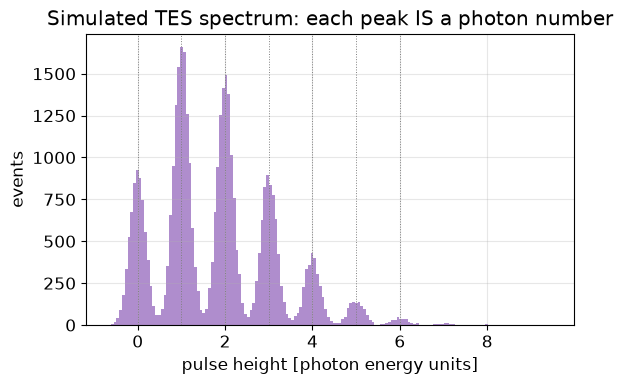

Resolved peaks at n = 0, 1, 2, ... - photon counting as calorimetry.
Peak areas reproduce P(n): here Poisson with nbar = 1.8


In [5]:
# Simulated TES pulse-height spectrum: counting photons by energy.
nbar = 1.8                        # mean photon number of the (coherent) probe
resolution = 0.18                 # energy resolution, sigma in photon units
n_events = 40_000

n_true = rng.poisson(nbar, n_events)                    # photons per pulse
pulse_height = n_true + rng.normal(0, resolution, n_events)

fig, ax = plt.subplots()
ax.hist(pulse_height, bins=160, color="tab:purple", alpha=0.75)
for n in range(7):
    ax.axvline(n, color="gray", lw=0.7, ls=":")
ax.set_xlabel("pulse height [photon energy units]")
ax.set_ylabel("events")
ax.set_title("Simulated TES spectrum: each peak IS a photon number")
plt.tight_layout()
plt.show()
print("Resolved peaks at n = 0, 1, 2, ... - photon counting as calorimetry.")
print("Peak areas reproduce P(n): here Poisson with nbar =", nbar)

## 3.7 · Check your understanding

1. Prove $g^{(2)}(0) = 1 + Q/\bar n$ from the definitions. For a source with $\bar n = 0.01$ and measured $g^{(2)}(0) = 0.1$: what is $Q$? Which quantity would you rather put an error bar on?
2. An SPDC source produces perfect number correlation between signal and idler. If you ignore the idler, why is the signal arm *thermal*? (Hint: what does tracing out one half of $\sum_n \lambda^n|n,n\rangle$ leave?)
3. Your antibunching dip stops at $g^{(2)}(0) = 0.2$ instead of 0. Give three instrumental explanations and one measurement to discriminate among them. Which of the three also explains a *narrow spike* at $\tau$ = one dead time?
4. Design sketch: measure $g^{(3)}(0)$ with click detectors only. How does the required measurement time scale compared to $g^{(2)}$?
5. Narrabri measured $\theta_{\rm Sirius} \approx 6$ mas at $\lambda = 400$ nm. Estimate the baseline where the correlation has substantially decayed. Why did atmospheric turbulence not matter?

**Next (10:30, same room):** three mystery time-tag datasets — one thermal, one coherent, one single emitter. You get raw detector output; you deliver identifications with error bars: [`04_HandsOn_g2_HBT`](04_HandsOn_g2_HBT.ipynb).